# Class Assignment 3: Predicting digits using Feed Forward Network

Tasks:

1.  Load MNIST dataset using torch vision or manual raw data

2.  Flatten the 28x28 pixel images into a 784-element vector

3.  Normalize the pixel values to a range from 0 to 1 for more stable gradient learning

4.  Build your network.  Note that we have 10 classes (digit of 0 to 9)

5.  Train it and report your accuracy, precision, and recall.

6.  Find 2-3 similar images in the internet or generate it.  Try inference :)

Enjoy


# 0. Load libraries

In [269]:
import torch
import torch.nn as nn
import torch.nn.functional as F # adds some efficiency
from torch.utils.data import DataLoader # loads data in batches
from torchvision import datasets, transforms # standard datasets and image transformations


import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix # for evaluating results
import matplotlib.pyplot as plt # for plotting results
# ensures plots are shown in the notebook; this will render images as PNGs
# http source: https://github.com/microsoft/vscode-jupyter/wiki/Using-%25matplotlib-widget-instead-of-%25matplotlib-notebook,tk,etc
%matplotlib inline 


# Load MNIST dataset using torch vision or manual raw data

Let's model the <a href='https://en.wikipedia.org/wiki/MNIST_database'>MNIST dataset</a> using only linear layers.

We'll reshape the MNIST data from a 28x28 image to a flattened 1x784 vector to mimic a single row of 784 features.

PyTorch makes the MNIST dataset available through <a href='https://pytorch.org/docs/stable/torchvision/index.html'><tt><strong>torchvision</strong></tt></a>. 

The first time it's called, the dataset will be downloaded onto your computer to the path specified. From that point, torchvision will always look for a local copy before attempting another download.

### Define transform
As part of the loading process, we can apply multiple transformations (reshape, convert to tensor, normalize, etc.) to the incoming data.

For this exercise we only need to convert images to tensors. 

In [270]:
transform = transforms.ToTensor() # convert images to PyTorch tensors

In [271]:
train_data = datasets.MNIST(root='../datasets/ca3', train=True, download=True, transform=transform)
train_data


Dataset MNIST
    Number of datapoints: 60000
    Root location: ../datasets/ca3
    Split: Train
    StandardTransform
Transform: ToTensor()

### Load the test set
There's a companion set of MNIST data containing 10,000 records accessible by setting train=False. As before, torchvision will only download this once, and in the future will look for the local copy.

In [272]:
test_data = datasets.MNIST(root='../datasets/ca3', train=False, download=True, transform=transform)
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../datasets/ca3
    Split: Test
    StandardTransform
Transform: ToTensor()

In [273]:
type(test_data)

torchvision.datasets.mnist.MNIST

In [274]:
type(train_data[0])

tuple

In [275]:
train_data[0]
# data is already normaized to [0,1] range

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [276]:
len(train_data)

60000

In [277]:
len(train_data[0])

2

In [278]:
train_data[0][0].shape

torch.Size([1, 28, 28])

Calling the first record from <tt>train_data</tt> returns a two-item tuple. The first item is our 28x28 tensor representing the image. The second is a label, in this case the number "5".

In [279]:
image, label = train_data[0]
print('Shape:', image.shape, '\nLabel:', label)

Shape: torch.Size([1, 28, 28]) 
Label: 5


### View the image

Matplotlib can interpret pixel values through a variety of <a href='https://matplotlib.org/tutorials/colors/colormaps.html'>colormaps</a>.

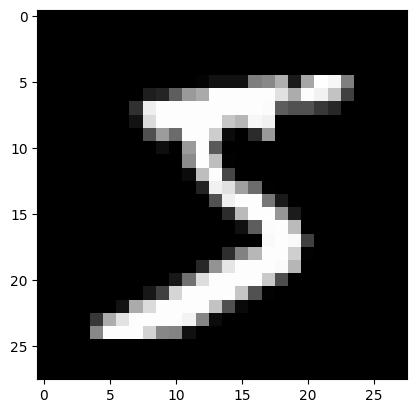

In [280]:
plt.imshow(train_data[0][0].reshape((28,28)), cmap='gray')

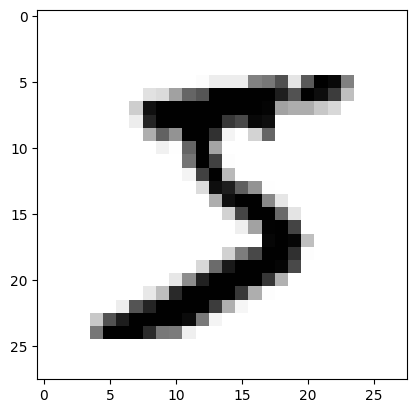

In [281]:
plt.imshow(train_data[0][0].reshape((28,28)), cmap="gist_yarg");

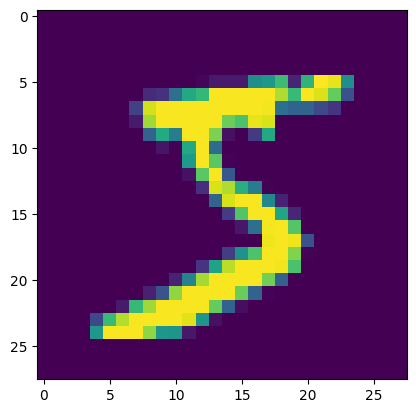

In [282]:
plt.imshow(train_data[0][0].reshape((28,28)));

### Batch loading with DataLoader
Our training set contains 60,000 records. If we look ahead to our model we have 784 incoming features, hidden layers of 120 and 84 neurons, and 10 output features. Including the bias terms for each layer, the total number of parameters being trained is:<br>

$\begin{align}\quad(784\times120)+120+(120\times84)+84+(84\times10)+10 &=\\
94080+120+10080+84+840+10 &= 105,214\end{align}$<br>

For this reason it makes sense to load training data in batches using <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader'><tt><strong>DataLoader</strong></tt></a>.

In [283]:
torch.manual_seed(101)  # for consistent results

train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=500, shuffle=False)

Labels:  [   7    2    3    5    8    5    3    6    9    9    1    3]


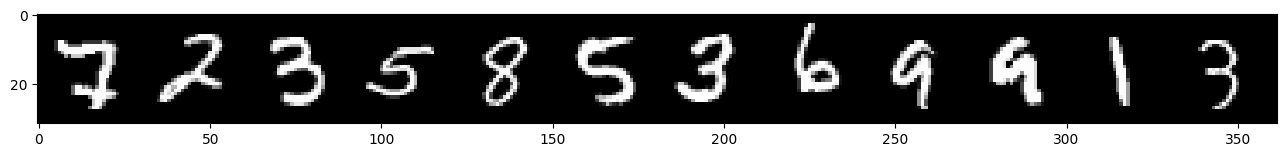

In [284]:
from torchvision.utils import make_grid
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}')) # to widen the printed array

# Grab the first batch of images
for images,labels in train_loader: 
    break

# Print the first 12 labels
print('Labels: ', labels[:12].numpy())

# Print the first 12 images
im = make_grid(images[:12], nrow=12)  # the default nrow is 8
plt.figure(figsize=(16,8))
# We need to transpose the images from CWH to WHC
# C - color chanel
# W - width
# H - height
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

# 2. Flatten the 28x28 pixel images into a 784-element vector

convert each 28×28 image to a 784-length vector (most fully-connected networks accept 1D vectors).

MNIST images are 28 × 28 pixels, grayscale.

That means each image is stored as a matrix: 
```python
  [
    [pixel, pixel, pixel, ... 28 columns],
    ...
    28 rows
  ]
```

But a fully-connected neural network (MLP) expects a 1D vector, not a 2D matrix. So we need to flatten our images.
Convert 28 × 28 → 784 numbers in a single row.
Flattening means stacking all rows into one long vector:
```python
[ pixel_1, pixel_2, pixel_3, ..., pixel_784 ]
```


✔ Why do we flatten?

Because MLP layers expect input like:

\[
x = [x_1, x_2, x_3, \..., x_{784}]
\]


— not a 2D grid.

✔ In PyTorch:

You can flatten manually:

```python
x = x.view(-1, 28*28)
```

Or automatically via:
```python
nn.Flatten()
```



# 3. Normalize the pixel values to a range from 0 to 1 for more stable gradient learning

MNIST pixels are originally integers in:

0 (black) to 255 (white)


Neural networks learn much better when inputs are small and in a consistent scale, so we convert 0–255 to 0–1:

✔ Normalization formula:


$x_{\text{normalized}} = \frac{x}{255}$



```python
    Example:

    0 → 0
    255 → 1
    127 → 0.5
```

Why normalize?

Because:

- Gradients become stable
- Training becomes faster
- Loss decreases earlier
- Prevents exploding values
- Makes learning smooth


`transforms.ToTensor()` does two things

1. Converts PIL Image to PyTorch Tensor
2. Automatically normalizes pixel values from [0, 255] to [0.0, 1.0]



# 4. Build your network.  Note that we have 10 classes (digit of 0 to 9)

### Batch loading with DataLoader
Our training set contains 60,000 records. If we look ahead to our model we have 784 incoming features, hidden layers of 120 and 84 neurons, and 10 output features. Including the bias terms for each layer, the total number of parameters being trained is:<br>

$\begin{align}\quad(784\times120)+120+(120\times84)+84+(84\times10)+10 &=\\
94080+120+10080+84+840+10 &= 105,214\end{align}$<br>

For this reason it makes sense to load training data in batches using <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader'><tt><strong>DataLoader</strong></tt></a>.


Our input size is 784 once we flatten the incoming 28x28 tensors.

Our output size represents the 10 possible digits.

We'll set our hidden layers to [120, 84] for now.  You can try any number.... Let's try with [256, 128]



### Use Multi - Layer Perceptron

What is MLP ?

Perceptron = a single artificial neuron

Multi-layer = you have multiple layers of these neurons stacked

Fully connected = every neuron connects to every neuron in the next layer
```python
    # Example structure
    Input layer  →  Hidden layer(s)  →  Output layer
```


In [285]:
import torch.nn.functional as F

class MultiLayerPerceptron(nn.Module):
    def __init__(self, in_sz=784, out_sz=10, layers=[256, 128]):
        super().__init__()
        # Flatten the 28x28 images into 784 element vectors
        self.flatten = nn.Flatten()
        # Buiild the network architecture
        self.net = nn.Sequential(
            nn.Linear(in_sz, layers[0]),
            nn.ReLU(),
            nn.Linear(layers[0], layers[1]),
            nn.ReLU(),
            nn.Linear(layers[1], out_sz)
        )

    def forward(self, x):
        # Flatten the input tensor
        x = self.flatten(x)
        # Pass the flattened tensor through the network
        return F.log_softmax(self.net(x), dim=1)
    #multi class classification
    # dim (int) – A dimension along which Softmax will be computed (so every slice along dim will sum to 1).


<div class="alert alert-info"><strong>NOTE:</strong> RELU can be used in functional approach too. 
F.relu(x) is just a function call that takes a tensor (like a list of numbers) and replaces every negative value with zero. You use it inside forward like this:
<pre style='background-color:rgb(217,237,247)'>

  x = F.relu(self.fc1(x))
  
</pre>


nn.ReLU() is a layer object. You first create it in <tt>__init__<tt> and then use it in forward, like calling a function:

<pre style='background-color:rgb(217,237,247)'>
  self.relu = nn.ReLU()
    ...  
  x = self.relu(self.fc1(x))
</pre>
They do the exact same math. The only difference is how you write the code:
- F.relu is quicker when you just need to apply ReLU once or aren’t reusing it.
- nn.ReLU is handy if you’re building layer lists (nn.Sequential), attaching hooks, or want it to show up in model summaries.
Both are fine; pick whichever style matches your model structure.


Key differences and practical notes

- Type:

    - nn.ReLU() — an nn.Module instance (layer).
    - torch.nn.functional.relu(x) (often F.relu(x)) — a stateless function.


- When to use which:

    - Use nn.ReLU() inside nn.Sequential or when you prefer activations to be attributes of the model (readability, inspectability).
    - Use F.relu(x) inside forward when you prefer a functional style or need to combine it with other ops inline.


- In-place option:

    - Both support in-place: nn.ReLU(inplace=True) or F.relu(x, inplace=True). In-place saves memory but can cause problems if you need the original tensor for gradient computations — use carefully.


- Device / state / saving:

    - nn.ReLU() is a module so it is included in model.children()/state_dict() traversal (even though it has no parameters). Modules are moved with model.to(device) automatically.
    - F.relu is purely a function and has no device/state concerns (it operates on the input tensor).


- Scripting / readability:

    - nn.ReLU() makes the architecture explicit (good for torch.jit.trace/script readability and visualization).
    - F.relu keeps code compact for custom forward logic.


- Performance:

    - No meaningful runtime difference; choose for code clarity and model structure.

In [286]:
torch.manual_seed(101)
# model = MultiLayerPerceptron(layers=[120, 84])
model = MultiLayerPerceptron(layers=[256, 128])
model

MultiLayerPerceptron(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [287]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

In [288]:
count_parameters(model)

200704
   256
 32768
   128
  1280
    10
______
235146


# 5. Train it and report your accuracy, precision, and recall.

This time we'll run the test data through the model during each epoch, so that we can compare loss & accuracy on the same plot.

<div class="alert alert-info"><strong>A QUICK NOTE: </strong>In the section below marked &nbsp;<tt><em>#Tally the number of correct predictions</em></tt> &nbsp;we include the code
<pre style='background-color:rgb(217,237,247)'>
predicted = torch.max(y_pred.data, 1)[1]</pre>
This uses the <a href='https://pytorch.org/docs/stable/torch.html#torch.max'><tt><strong>torch.max()</strong></tt></a> function. <tt>torch.max()</tt> returns a tensor of maximum values, and a tensor of the indices where the max values were found. In our code we're asking for the index positions of the maximum values along dimension 1. In this way we can match predictions up to image labels.</div>

In [289]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [290]:
type(train_loader)

torch.utils.data.dataloader.DataLoader

In [291]:
import time
start_time = time.time()

epochs = 10
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        b+=1
        
        # Apply the model
        # y_pred = model(X_train.view(100, -1))  # Here we flatten X_train
        y_pred = model(X_train)  # No need flatten, done in model
        loss = criterion(y_pred, y_train)
 
        #y_pred - one hot encoding softmax values [0.1,0.0,0.8, ...]

        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print interim results
        if b%200 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{100*b:6}/60000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(100*b):7.3f}%')
    
    # Update train loss & accuracy for the epoch
    train_losses.append(loss)
    train_correct.append(trn_corr)
        
    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):

            # Apply the model
            # y_val = model(X_test.view(500, -1))  # Here we flatten X_test to 500 samples - size of the batch
            y_val = model(X_test)  # No need flatten, done in model
            
            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()
    
    # Update test loss & accuracy for the epoch
    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)
        
print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed            

epoch:  0  batch:  200 [ 20000/60000]  loss: 0.20885044  accuracy:  85.010%
epoch:  0  batch:  400 [ 40000/60000]  loss: 0.36743575  accuracy:  88.843%
epoch:  0  batch:  600 [ 60000/60000]  loss: 0.30205640  accuracy:  90.672%
epoch:  1  batch:  200 [ 20000/60000]  loss: 0.15065478  accuracy:  95.595%
epoch:  1  batch:  400 [ 40000/60000]  loss: 0.04588136  accuracy:  95.892%
epoch:  1  batch:  600 [ 60000/60000]  loss: 0.06806335  accuracy:  96.128%
epoch:  2  batch:  200 [ 20000/60000]  loss: 0.13094106  accuracy:  97.330%
epoch:  2  batch:  400 [ 40000/60000]  loss: 0.07729202  accuracy:  97.418%
epoch:  2  batch:  600 [ 60000/60000]  loss: 0.02627280  accuracy:  97.478%
epoch:  3  batch:  200 [ 20000/60000]  loss: 0.04873925  accuracy:  98.070%
epoch:  3  batch:  400 [ 40000/60000]  loss: 0.00923007  accuracy:  98.125%
epoch:  3  batch:  600 [ 60000/60000]  loss: 0.06452789  accuracy:  98.165%
epoch:  4  batch:  200 [ 20000/60000]  loss: 0.07606961  accuracy:  98.770%
epoch:  4  b

In [292]:
print(predicted)

tensor([2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 4, 1, 0, 1, 2, 7, 5,
        3, 4, 4, 0, 0, 6, 9, 6, 6, 5, 7, 2, 3, 4, 4, 9, 1, 4, 0, 7, 9, 5, 7, 2,
        3, 1, 4, 4, 0, 9, 9, 6, 1, 8, 3, 3, 7, 3, 9, 8, 8, 4, 7, 7, 6, 2, 1, 9,
        8, 7, 8, 8, 7, 2, 2, 3, 9, 3, 3, 5, 5, 0, 7, 4, 5, 6, 5, 1, 4, 1, 1, 2,
        8, 2, 6, 1, 5, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8,
        9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 8, 0, 6, 0, 0, 2, 3, 7, 9, 4, 7, 1, 9, 1,
        7, 1, 4, 0, 0, 1, 7, 5, 7, 1, 3, 3, 3, 1, 6, 9, 7, 1, 3, 0, 7, 6, 0, 8,
        9, 7, 3, 5, 4, 8, 1, 5, 9, 0, 6, 3, 3, 8, 1, 4, 7, 5, 2, 0, 0, 1, 7, 8,
        9, 6, 8, 8, 2, 3, 6, 1, 2, 9, 5, 2, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
        2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 6, 6, 7, 8, 9, 7, 4, 6, 1, 4, 0,
        9, 9, 3, 7, 8, 0, 7, 5, 8, 5, 3, 2, 2, 0, 5, 8, 6, 0, 3, 8, 1, 0, 3, 0,
        4, 7, 4, 9, 0, 9, 0, 7, 1, 7, 1, 6, 6, 0, 6, 2, 8, 7, 6, 4, 9, 9, 5, 3,
        7, 4, 3, 0, 7, 6, 6, 1, 1, 3, 2,

### Plot the loss and accuracy comparisons

In [293]:
train_losses = [loss.item() for loss in train_losses]
test_losses  = [loss.item() for loss in test_losses]

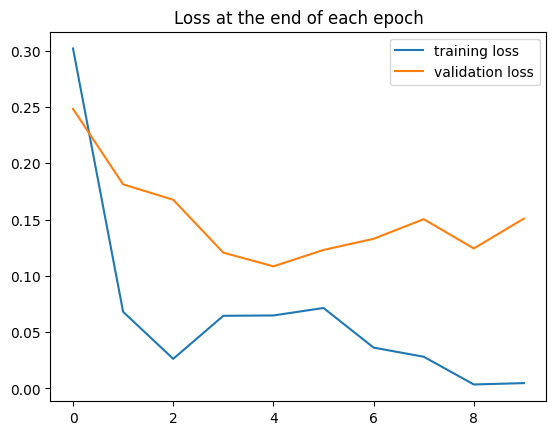

In [294]:
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();

### What the plot shows ?

#### 1. Training loss: consistently decreasing

- Starts high (~0.3)

- Drops sharply at epoch 1

- Continues decreasing

- Ends extremely low (~0.005)
<div class="alert alert-info"><strong>OBSERVATION: </strong>
    <pre style='background-color:rgb(217,237,247)'>
    This means the model is learning from the training data very well.
    It is fitting the patterns increasingly accurately.
    </pre>
</div>

#### 2. Validation loss: decreases, then fluctuates

- Starts around 0.25

- Drops steadily for several epochs

- Hits a low point (around epoch 3–4)

- Then begins to wiggle up and down

- Ends around ~0.12 or so

<div class="alert alert-info"><strong>OBSERVATION: </strong>
    <pre style='background-color:rgb(217,237,247)'>
This means the model generalizes fairly well, but not perfectly.
After some point, the model slightly overfits.
    </pre>
</div>

### Key observations
#### Early epochs (0–4): Good learning

- Training loss ↓ ( Dropping )

- Validation loss ↓ ( Dropping)

** Both decreasing = healthy training, model learning general patterns.

#### Later epochs (5–9): Possible mild overfitting

- Training loss keeps decreasing sharply (almost to zero)

- Validation loss begins to flatten and oscillate

** At some epochs, validation loss increases while training loss decreases

*** This is the classic sign of overfitting.
*** Model fits training data too perfectly, but validation (unseen) data not improving.

#### Does overfitting mean your model is bad?

No — this is actually a very normal training curve.

The validation loss still remains low and not diverging massively.

This means: Model generalization is still good. Overfitting is small. Training succeeded


## Final Takeaway

The training loss decreases steadily and approaches zero, indicating that the model fits the training data well.
The validation loss also decreases initially, reaching a minimum around epoch 3–4, but then fluctuates slightly, suggesting mild overfitting after the early epochs.
Overall, the model shows good learning performance with only slight overfitting.

#### How to improve the validation loss?

To match curves more closely, we can perform few things 

- Increase dropout

- Use early stopping (stop training at epoch 3–4)

- Add L2 regularization

- Reduce model size


#### How to reduce overfitting?

Here are standard techniques:

✔ Early Stopping

Stop training when validation loss stops decreasing.

✔ Dropout

Randomly turn off neurons → reduces memorization.

✔ L2 regularization

Penalizes large weights.

✔ More data

Harder for the model to memorize noise.

✔ Data augmentation

Modify training samples (in images: rotation, cropping).

✔ Reduce model size

Simplify network architecture.

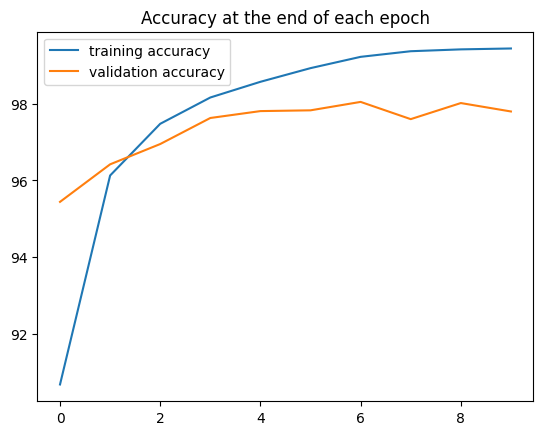

In [295]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();

#### 1. What is this graph?

This graph shows how accurately your model predicted the correct labels during each epoch:

Training accuracy: accuracy on data the model saw during training

Validation accuracy: accuracy on unseen data (used to measure generalization)

#### 2. What does the graph tell us?

Let’s analyze it:

✔ Training accuracy

- Starts around 90–91%

- Increases rapidly

- Keeps improving to 99%

This means:
👉 The model is learning the training data very well.

This is expected — models improve on the data they train on.

✔ Validation accuracy

- Starts around 95%

- Quickly rises to around 98%

- Then plateaus around 98%, with tiny ups and downs

This means:
👉 The model is doing very well on unseen data too.
👉 About 98% validation accuracy is very good for MNIST using an MLP.

#### 3. Is this overfitting? Underfitting? Or good fitting?

Let’s evaluate:

##### Underfitting?

- No.

Underfitting would show:

Low training accuracy

Low validation accuracy

The  model clearly does much better than that.

##### Overfitting?

- A little bit, but very mild.

- Overfitting would show:

- Training accuracy keeps increasing

- Validation accuracy drops or gets worse

- Here, the validation accuracy stays almost flat (97–98%).

👉 This means the model generalizes well.

Overfitting is present only slightly because:

- Training accuracy is 99%

- Validation accuracy stays around 98%

- A 1% gap is normal and not a problem.

### Conclusion: This is a slightly overfitted model

The  model:

- Learns the data well

- Generalizes to new data

- Only slightly overfits

- Performs close to the best possible performance for an MLP on MNIST


## Precision and Recall

In [296]:
# Run once: requires scikit-learn installed
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, precision_recall_fscore_support

import torch
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        logits = model(X)                    # raw logits
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Per-class & averaged metrics
print("Precision (macro):", precision_score(all_labels, all_preds, average='macro', zero_division=0))
print("Recall    (macro):", recall_score(all_labels, all_preds, average='macro', zero_division=0))

# Full classification report
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")


# Confusion matrix (useful to compute manual per-class precision/recall)
cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

Precision (macro): 0.9782022974107768
Recall    (macro): 0.9775563754834703
              precision    recall  f1-score   support

           0     0.9778    0.9908    0.9843       980
           1     0.9956    0.9877    0.9916      1135
           2     0.9533    0.9893    0.9710      1032
           3     0.9763    0.9802    0.9783      1010
           4     0.9757    0.9807    0.9782       982
           5     0.9953    0.9484    0.9713       892
           6     0.9753    0.9875    0.9813       958
           7     0.9795    0.9767    0.9781      1028
           8     0.9781    0.9641    0.9710       974
           9     0.9751    0.9703    0.9727      1009

    accuracy                         0.9780     10000
   macro avg     0.9782    0.9776    0.9778     10000
weighted avg     0.9782    0.9780    0.9780     10000

Precision: 0.9782, Recall: 0.9776, F1-score: 0.9778
Confusion matrix:
 [[ 971    0    2    0    0    0    3    2    1    1]
 [   0 1121    4    2    0    0    2    2

In [297]:
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

for digit in range(10):
    print(f"Digit {digit}:")
    print(f"  TP: {TP[digit]}")
    print(f"  FP: {FP[digit]}")
    print(f"  FN: {FN[digit]}")
    print(f"  TN: {TN[digit]}")
    print()


Digit 0:
  TP: 971
  FP: 22
  FN: 9
  TN: 8998

Digit 1:
  TP: 1121
  FP: 5
  FN: 14
  TN: 8860

Digit 2:
  TP: 1021
  FP: 50
  FN: 11
  TN: 8918

Digit 3:
  TP: 990
  FP: 24
  FN: 20
  TN: 8966

Digit 4:
  TP: 963
  FP: 24
  FN: 19
  TN: 8994

Digit 5:
  TP: 846
  FP: 4
  FN: 46
  TN: 9104

Digit 6:
  TP: 946
  FP: 24
  FN: 12
  TN: 9018

Digit 7:
  TP: 1004
  FP: 21
  FN: 24
  TN: 8951

Digit 8:
  TP: 939
  FP: 21
  FN: 35
  TN: 9005

Digit 9:
  TP: 979
  FP: 25
  FN: 30
  TN: 8966



In [298]:
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s, supports = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(10))
)

for digit in range(10):
    print(f"Digit {digit}:")
    print(f"  Precision: {precisions[digit]:.4f}")
    print(f"  Recall:    {recalls[digit]:.4f}")
    print(f"  F1-score:  {f1s[digit]:.4f}")
    print(f"  Support:   {supports[digit]}")
    print()


Digit 0:
  Precision: 0.9778
  Recall:    0.9908
  F1-score:  0.9843
  Support:   980

Digit 1:
  Precision: 0.9956
  Recall:    0.9877
  F1-score:  0.9916
  Support:   1135

Digit 2:
  Precision: 0.9533
  Recall:    0.9893
  F1-score:  0.9710
  Support:   1032

Digit 3:
  Precision: 0.9763
  Recall:    0.9802
  F1-score:  0.9783
  Support:   1010

Digit 4:
  Precision: 0.9757
  Recall:    0.9807
  F1-score:  0.9782
  Support:   982

Digit 5:
  Precision: 0.9953
  Recall:    0.9484
  F1-score:  0.9713
  Support:   892

Digit 6:
  Precision: 0.9753
  Recall:    0.9875
  F1-score:  0.9813
  Support:   958

Digit 7:
  Precision: 0.9795
  Recall:    0.9767
  F1-score:  0.9781
  Support:   1028

Digit 8:
  Precision: 0.9781
  Recall:    0.9641
  F1-score:  0.9710
  Support:   974

Digit 9:
  Precision: 0.9751
  Recall:    0.9703
  F1-score:  0.9727
  Support:   1009



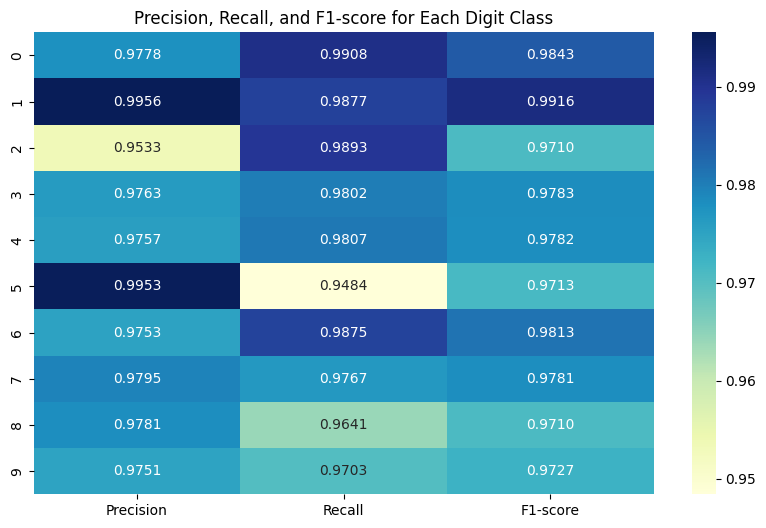

In [299]:
# plot heatmap of precision, recall, f1-score for each class
import seaborn as sns
import matplotlib.pyplot as plt
metrics_df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls,
    'F1-score': f1s
}, index=[f'{i}' for i in range(10)])
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Precision, Recall, and F1-score for Each Digit Class")
plt.show()

#### 1. Digit-by-Digit Interpretation from Heatmap

Let’s interpret the standout patterns:

##### Digit 1 — Very Dark Blue (Excellent)

Precision: 0.9956
Recall: 0.9877
F1: 0.9916

👉 The model almost never misclassifies "1"
👉 Strong and consistent performance

##### Digit 5 — Recall is light colored (weaker)

Precision: 0.9953 (dark → great)
Recall: 0.9484 (light → lowest in all digits)

👉 The model is very confident when it predicts "5" (precision)
👉 BUT it misses many actual "5"s (poor recall)

##### Interpretation:
Digit 5 is the hardest for the model to detect (high false negatives).

Reason: handwritten 5 often resembles 3, 8, or even 6.

##### Digit 8 — Medium color (slightly weaker)

Recall: 0.9641

👉 The model sometimes misses digits that are actually "8".
👉 Handwritten 8s vary a lot and get confused with 3 or 9.

#####  Digits 0, 1, 3, 4, 6, 7 — Strong performance

All metrics > 0.98
Dark blue color

👉 These digits are the easiest for the model.

##### 2. What Precision vs Recall Means in This Heatmap

High Precision (dark)

Means: 

- When the model predicts that digit, it is usually correct.

- Few false positives.

High Recall (dark)

Means:

- The model catches almost every real sample of that digit.

- Few false negatives.

- Lower Recall for digit 5 & 8 (lighter)

Means:

The model fails to detect some real 5s and 8s.

It misclassifies them as other digits.

##### 3. F1-score column

F1 blends both precision & recall:

High F1 = both precision and recall are strong

Lower F1 (greenish color) = one of the two is weaker (usually recall)

Digit 5 F1 is lower because recall is low.

#### Final Summary 

The heatmap shows precision, recall, and F1-score for each digit class.
Most digits (0, 1, 3, 4, 6, 7, 9) are dark colored across all metrics, indicating very strong and consistent performance above 0.97.
Digits 5 and 8 show lighter colors in the recall column, revealing that the model often misses true instances of these digits. This suggests common confusion with similar-looking digits (e.g., 5 ↔ 3, 8 ↔ 3/9).
Overall, the model demonstrates high accuracy and strong generalization, with minor weaknesses on digits 5 and 8.

#### 1. Which digits are misclassified the most?

We use recall to detect missed digits:
Recall = TP / (TP + FN)

Low recall → high FN → many misclassifications.

From your per-class recall:

Digit	Recall	Miss Rate (1–Recall)
5	0.9484	5.16%
8	0.9641	3.59%
9	0.9703	2.97%
7	0.9767	2.33%
3	0.9802	1.98%
4	0.9807	1.93%
6	0.9875	1.25%
1	0.9877	1.23%
2	0.9893	1.07%
0	0.9908	0.92%
✔ Most misclassified digits = 5 and 8

Digit 5 → worst recall
Digit 8 → second worst recall

These digits are trickier because handwriting styles vary a lot.

#### 2. Why are 5 and 8 misclassified more?

Digit 5 - Often looks like: 3 6 8

Sometimes sloppy “5” looks similar to “9”

Your heatmap likely shows mistakes spreading across those classes.

Digit 8

Often confused with:

3 (closed top)

9

messy handwritten loops

These digits share similar loops/curves.

#### 3. How to fix low recall for digits 5 and 8

These are real, practical machine learning improvements.

##### Fix 1 — Use a Convolutional Neural Network (CNN)

MLP (Fully Connected network) ignores spatial structure.
A CNN sees edges, curves, loops, which are EXACTLY what distinguish 5 and 8.

Switching to CNN will immediately boost accuracy to 99.2%+ and improve confusing digits.

##### Fix 2 — Increase Model Capacity (More Hidden Units or Layers)

Add more neurons

Add one more hidden layer

Use ReLU vs. Sigmoid (you already use ReLU, good)

BUT be careful: too large → overfitting.
Add dropout to stabilize.

##### Fix 3 — Data Augmentation

Add slight variations to training digits, so model learns more robust features:

Most common:

transforms.RandomRotation(10)
transforms.RandomAffine(0, shear=10, scale=(0.8,1.2))


This helps especially for 5 and 8 (handwriting varies a lot).

##### Fix 4 — Class Balancing

MNIST is already balanced, but you can:

Oversample misclassified classes (5 & 8)

Or weight the loss:

criterion = nn.CrossEntropyLoss(weight=class_weights)


Where class_weights[5] > class_weights[0].

This forces model to care more about correctly detecting 5 and 8.

##### Fix 5 — Reduce Overfitting

Your train accuracy is 99%, validation ~98%.
Small gap → mild overfitting.

To reduce overfitting (which hurts recall), you can:

Increase dropout (0.2 → 0.3 or 0.4)

Use L2 regularization

Reduce training epochs slightly (early stopping)

##### Fix 6 — Tune the Learning Rate

Sometimes:

Too high LR → model converges to suboptimal features

Too low LR → model doesn’t learn harder classes well

Try learning rate schedules:

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

##### Fix 7 — Confusion-Specific Training

Train model more on digits it struggles with:

Extract all misclassified 5s and 8s

Fine-tune model on them

This is called hard example mining

#### 4. Summary

Digits 5 and 8 are misclassified the most, as shown by their lower recall values. These digits have higher within-class variation and visual similarity to other digits (e.g., 5 ↔ 3 or 8 ↔ 9).

To improve recall for these digits, we can use CNNs, apply data augmentation, increase model capacity, use loss weighting, reduce overfitting through dropout or early stopping, tune the learning rate, or apply hard example mining. These techniques help the model learn more robust and discriminative features, especially for visually ambiguous digits.

# Error analysis and examine the misses

In [300]:
misses = np.array([])
for i in range(len(predicted.view(-1))):
    if predicted[i] != y_test[i]:
        misses = np.append(misses,i).astype('int64')

# Display the number of misses
len(misses)

14

Index: [  17   87  164  169  179  229  245]
Label: [   9    9    2    4    6    5    4]
Guess: [   4    4    7    7    3    6    0]


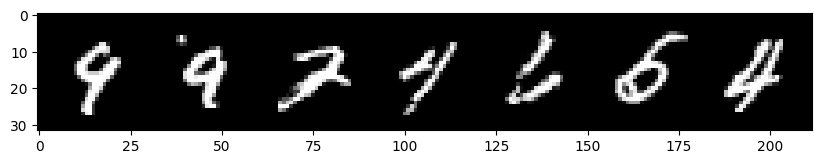

In [301]:
# Set up an iterator to feed batched rows
r = 12   # row size
row = iter(np.array_split(misses,len(misses)//r+1))

nextrow = next(row)
print("Index:", nextrow)
print("Label:", y_test.index_select(0,torch.tensor(nextrow)).numpy())
print("Guess:", predicted.index_select(0,torch.tensor(nextrow)).numpy())

images = X_test.index_select(0,torch.tensor(nextrow))
im = make_grid(images, nrow=r)
plt.figure(figsize=(10,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

# 6. Find 2-3 similar images in the internet or generate it.  Try inference


In [314]:
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as transforms

# same normalization as training
transform = transforms.Compose([
    transforms.Grayscale(),          # convert to 1 channel
    transforms.Resize((28,28)),      # match MNIST size
    transforms.ToTensor(),           # convert to [0,1] range
    transforms.Normalize((0.1307,), (0.3081,))
])

def load_and_predict(image_path, model):
    img = Image.open(image_path)
    x = transform(img)
    x = x.unsqueeze(0)  # shape: (1,1,28,28)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
        prob = torch.softmax(logits, dim=1)[0][pred].item()
    print(f"Predicted digit: {pred}   (confidence: {prob:.4f})")


In [315]:
# Image location for inference
image_location = '../datasets/ca3/inference'
img_path = image_location + '/three.png'

load_and_predict(image_location + '/three.png', model)
load_and_predict(image_location + '/five.png', model)
load_and_predict(image_location + '/one.png', model)


# predict simpe ones
load_and_predict(image_location + '/three2.png', model)
load_and_predict(image_location + '/five2.png', model)


Predicted digit: 5   (confidence: 1.0000)
Predicted digit: 5   (confidence: 0.9629)
Predicted digit: 5   (confidence: 1.0000)
Predicted digit: 5   (confidence: 1.0000)
Predicted digit: 5   (confidence: 1.0000)


In [316]:
load_and_predict(image_location + '/hw1.png', model)
load_and_predict(image_location + '/hw2.png', model)
load_and_predict(image_location + '/hw3.png', model)

Predicted digit: 5   (confidence: 1.0000)
Predicted digit: 5   (confidence: 1.0000)
Predicted digit: 5   (confidence: 1.0000)
